# 3. Problem Discovery — How Did We Identify the Problem?

The story is selected from exploratory evidence, not assumed in advance.

For each customer, `max_collaborators` is the largest collaborator count
observed across products and months — the greatest observed collaboration
reach. `mean_collaborators` is retained as a sensitivity check (used in
stage 5).

**Why it matters:** the tiers proposed in stage 4 are only useful if the
data contains a meaningful high-collaboration tail with enough
observations to analyse — this stage checks that before any tier is
defined.

In [1]:
from common import ARTIFACTS, BLUE, PURPLE, GREY, LIGHT_GREY, AMBER, save_show
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

customers = pd.read_parquet(ARTIFACTS / "customers.parquet")
tickets = pd.read_parquet(ARTIFACTS / "tickets.parquet")
usage = pd.read_parquet(ARTIFACTS / "usage.parquet")
print(f"Loaded {len(customers):,} customers, {len(tickets):,} tickets, {len(usage):,} usage rows.")

Loaded 8,320 customers, 8,469 tickets, 42,210 usage rows.


## 3.1 Aggregate Usage to Customer Grain

42,210 monthly usage rows become one row per customer — required before
joining to tickets, or a ticket-to-usage join would repeat each ticket for
every monthly usage row (flagged as a risk back in stage 1).

In [2]:
usage_customer = usage.groupby("customer_id", as_index=False).agg(
    max_collaborators=("collaborators", "max"),
    mean_collaborators=("collaborators", "mean"),
    usage_rows=("collaborators", "size"),
)
customer_view = customers.merge(
    usage_customer, on="customer_id", how="left", validate="one_to_one"
)
assert len(customer_view) == len(customers)
assert customer_view["max_collaborators"].notna().all()
customer_view["non_free_plan"] = customer_view["plan_type"].ne("Free")
print(f"customer_view: {len(customer_view):,} rows, one per customer.")

customer_view: 8,320 rows, one per customer.


In [3]:
ticket_view = tickets.merge(
    customer_view[[
        "customer_email", "customer_id", "plan_type", "company_size",
        "max_collaborators", "mean_collaborators", "non_free_plan",
    ]],
    on="customer_email", how="left", validate="many_to_one",
)
assert len(ticket_view) == len(tickets)
assert ticket_view["customer_id"].notna().all()
ticket_view["high_priority"] = ticket_view["ticket_priority"].isin(["High", "Critical"])
print(f"ticket_view: {len(ticket_view):,} rows, one per ticket.")

ticket_view: 8,469 rows, one per ticket.


## 3.2 Distribution of Maximum Collaboration Reach

Marks 18 and 20 as candidate policy boundaries — these become the tier
cutoffs in stage 4, chosen from where this distribution actually shows a
tail, not picked arbitrarily beforehand.

In [4]:
exact_customer = customer_view.groupby("max_collaborators").agg(
    customers=("customer_id", "size"),
    non_free_rate=("non_free_plan", "mean"),
)
exact_ticket = ticket_view.groupby("max_collaborators").agg(
    tickets=("ticket_id", "size"),
    high_priority_rate=("high_priority", "mean"),
)
exact_reach = exact_customer.join(exact_ticket)
print("Exact-reach summary built.")

Exact-reach summary built.


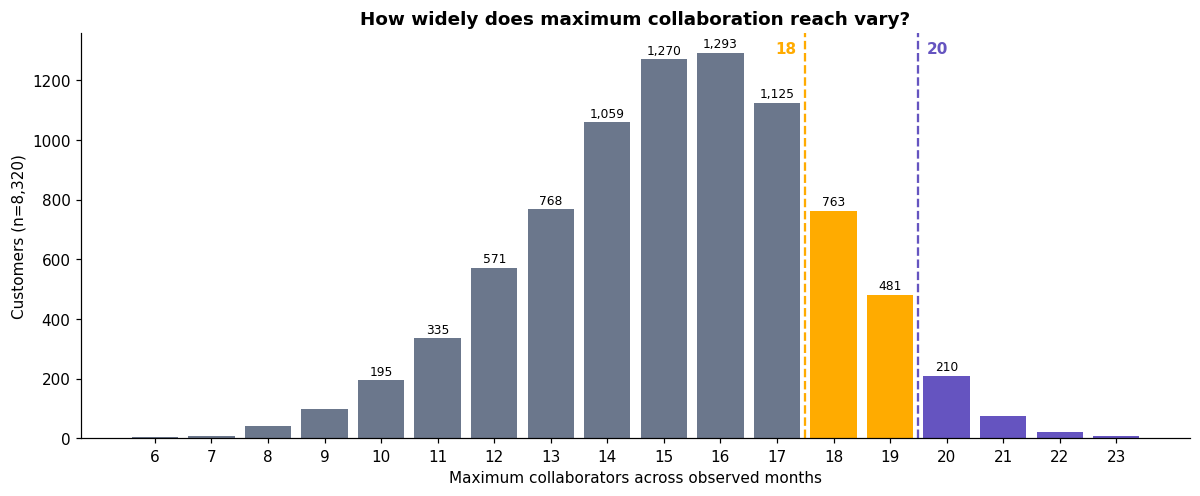

**Observed:** maximum reach spans **6 to 23 collaborators**. **Meaning:** the data contains typical customers and a small high-reach tail. **Limitation:** this is a maximum monthly count, not a live network size.

In [5]:
fig, ax = plt.subplots(figsize=(10.8, 4.4), layout="constrained")
colors = [GREY if reach <= 17 else AMBER if reach <= 19 else PURPLE for reach in exact_customer.index]
bars = ax.bar(exact_customer.index, exact_customer["customers"], color=colors, width=.82)
for bar, value in zip(bars, exact_customer["customers"]):
    if value >= 100:
        ax.text(bar.get_x() + bar.get_width()/2, value + 18, f"{value:,}", ha="center", fontsize=8)
ax.axvline(17.5, color=AMBER, linestyle="--", linewidth=1.5)
ax.axvline(19.5, color=PURPLE, linestyle="--", linewidth=1.5)
ax.text(17.35, ax.get_ylim()[1] * .95, "18", color=AMBER, ha="right", fontweight="bold")
ax.text(19.65, ax.get_ylim()[1] * .95, "20", color=PURPLE, ha="left", fontweight="bold")
ax.set(
    title="How widely does maximum collaboration reach vary?",
    xlabel="Maximum collaborators across observed months",
    ylabel=f"Customers (n={len(customer_view):,})",
)
ax.set_xticks(exact_customer.index)
save_show(fig, "03_collaboration_distribution.png")

display(Markdown(
    f"**Observed:** maximum reach spans **{int(exact_customer.index.min())} to "
    f"{int(exact_customer.index.max())} collaborators**. "
    f"**Meaning:** the data contains typical customers and a small high-reach tail. "
    f"**Limitation:** this is a maximum monthly count, not a live network size."
))

## 3.3 Compare the Two Sides of the Proposed Blind Spot

Two rates at each exact collaborator count:
- **commercial-plan concentration:** customers on any plan other than Free
- **existing priority recognition:** tickets currently labelled High or Critical

Point size represents the denominator. Grey points have fewer than 50
observations and are visually separated, since their percentages can swing
sharply from only a few records.

**Decision logic:** if both lines rise together, current priority may
already account for collaboration. If non-Free concentration rises while
priority stays flat, the proposed blind spot remains plausible.

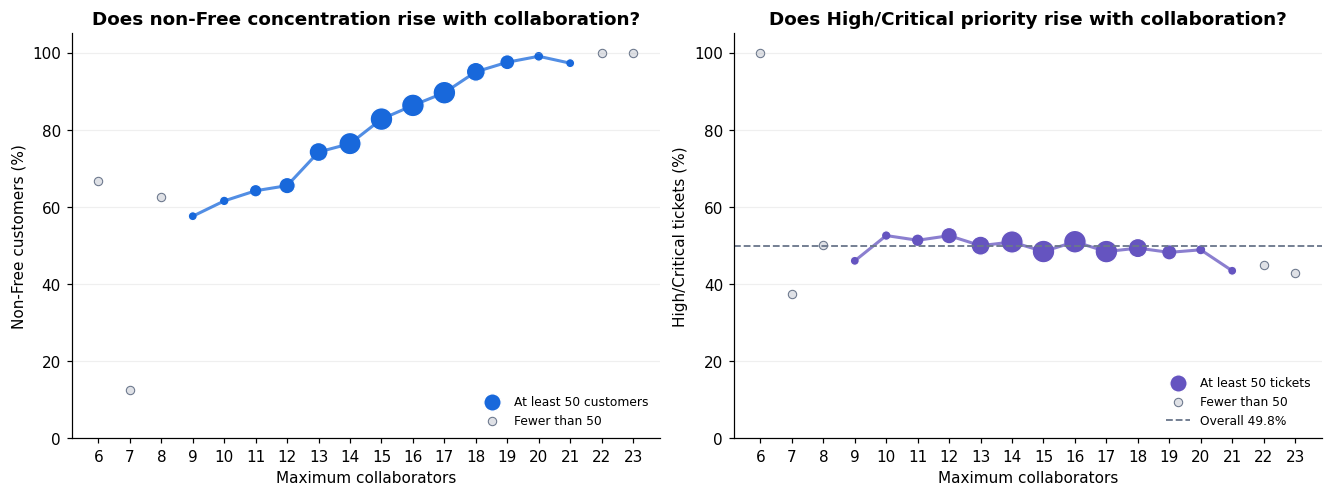

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), layout="constrained")
stable_customer = exact_reach["customers"] >= 50
stable_ticket = exact_reach["tickets"] >= 50

axes[0].plot(
    exact_reach.index[stable_customer], exact_reach.loc[stable_customer, "non_free_rate"] * 100,
    color=BLUE, linewidth=2, alpha=.75,
)
axes[0].scatter(
    exact_reach.index[stable_customer], exact_reach.loc[stable_customer, "non_free_rate"] * 100,
    s=np.clip(exact_reach.loc[stable_customer, "customers"] / 5, 35, 220),
    color=BLUE, edgecolor="white", linewidth=.8, label="At least 50 customers",
)
axes[0].scatter(
    exact_reach.index[~stable_customer], exact_reach.loc[~stable_customer, "non_free_rate"] * 100,
    s=30, color=LIGHT_GREY, edgecolor=GREY, linewidth=.7, label="Fewer than 50",
)
axes[0].set(
    title="Does non-Free concentration rise with collaboration?",
    xlabel="Maximum collaborators", ylabel="Non-Free customers (%)", ylim=(0, 105),
)

axes[1].plot(
    exact_reach.index[stable_ticket], exact_reach.loc[stable_ticket, "high_priority_rate"] * 100,
    color=PURPLE, linewidth=2, alpha=.75,
)
axes[1].scatter(
    exact_reach.index[stable_ticket], exact_reach.loc[stable_ticket, "high_priority_rate"] * 100,
    s=np.clip(exact_reach.loc[stable_ticket, "tickets"] / 5, 35, 220),
    color=PURPLE, edgecolor="white", linewidth=.8, label="At least 50 tickets",
)
axes[1].scatter(
    exact_reach.index[~stable_ticket], exact_reach.loc[~stable_ticket, "high_priority_rate"] * 100,
    s=30, color=LIGHT_GREY, edgecolor=GREY, linewidth=.7, label="Fewer than 50",
)
overall_priority_rate = ticket_view["high_priority"].mean()
axes[1].axhline(
    overall_priority_rate * 100, color=GREY, linestyle="--", linewidth=1.2,
    label=f"Overall {overall_priority_rate:.1%}",
)
axes[1].set(
    title="Does High/Critical priority rise with collaboration?",
    xlabel="Maximum collaborators", ylabel="High/Critical tickets (%)", ylim=(0, 105),
)
for ax in axes:
    ax.set_xticks(exact_reach.index)
    ax.grid(axis="y", alpha=.2)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
save_show(fig, "04_problem_discovery.png")

In [7]:
reach_17 = exact_reach.loc[17]
reach_20 = exact_reach.loc[20]
display(Markdown(f'''**Observed:** from 17 to 20 maximum collaborators, non-Free share rises from
**{reach_17.non_free_rate:.1%} (n={int(reach_17.customers):,})** to
**{reach_20.non_free_rate:.1%} (n={int(reach_20.customers):,})**. High/Critical share is
**{reach_17.high_priority_rate:.1%} (n={int(reach_17.tickets):,})** and
**{reach_20.high_priority_rate:.1%} (n={int(reach_20.tickets):,})**, respectively.

**Meaning:** commercial concentration rises sharply, while technical priority remains near the overall rate.
That mismatch is why Blast Radius was selected.

**Limitation:** grey points contain fewer than 50 observations and are not stable evidence.'''))

**Observed:** from 17 to 20 maximum collaborators, non-Free share rises from
**89.6% (n=1,125)** to
**99.0% (n=210)**. High/Critical share is
**48.4% (n=1,153)** and
**48.9% (n=219)**, respectively.

**Meaning:** commercial concentration rises sharply, while technical priority remains near the overall rate.
That mismatch is why Blast Radius was selected.

**Limitation:** grey points contain fewer than 50 observations and are not stable evidence.

## 3.4 Save for Downstream Stages

In [8]:
customer_view.to_parquet(ARTIFACTS / "customer_view.parquet")
ticket_view.to_parquet(ARTIFACTS / "ticket_view.parquet")
print("Saved: customer_view.parquet, ticket_view.parquet -> ./artifacts/")

Saved: customer_view.parquet, ticket_view.parquet -> ./artifacts/
